<a href="https://colab.research.google.com/github/NaraDaibes/Liver_damage_prediction/blob/Predictions-Of-Product-Sales/cirrhosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1950]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1951]:
# imports
import  pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split,  GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

In [1952]:
fpath='/content/drive/MyDrive/AXSOSACADEMY (1)/cirrhosis.csv'
df=pd.read_csv(fpath)
df.head(10)

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
5,6,2503,D,Placebo,24201,F,N,Y,N,N,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
6,7,1832,C,Placebo,20284,F,N,Y,N,N,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
7,8,2466,D,Placebo,19379,F,N,N,N,N,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
8,9,2400,D,D-penicillamine,15526,F,N,N,Y,N,3.2,562.0,3.08,79.0,2276.0,144.15,88.0,251.0,11.0,2.0
9,10,51,D,Placebo,25772,F,Y,N,Y,Y,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0


# **Cleaning**

In [1953]:
df.shape

(418, 20)

In [1954]:
df.duplicated().sum()

np.int64(0)

In [1955]:
df.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [1956]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [1957]:
df.isna().sum()

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


In [1958]:
# drop the rows with missing values in the target 'stage'
df = df.dropna(subset=['Stage'])
df.isna().sum()

,0
ID,0
N_Days,0
Status,0
Drug,100
Age,0
Sex,0
Ascites,100
Hepatomegaly,100
Spiders,100
Edema,0


In [1959]:
w=df[df[['Ascites','Hepatomegaly','Spiders','Tryglicerides','Cholesterol']].isna().all(axis=1)]
w
# drop w from data set
df=df.drop(w.index)
df.shape

(312, 20)

# **Exploratory Visualization**

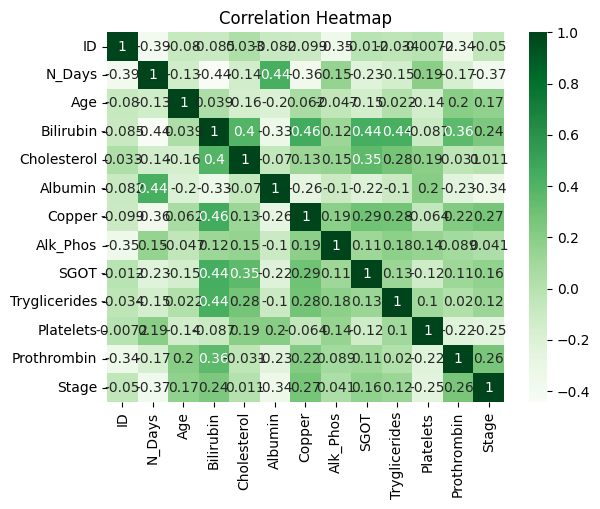

In [1960]:
corr=df.corr(numeric_only=True)
ax=sns.heatmap(corr,cmap='Greens', annot=True)
ax.set_title('Correlation Heatmap')
plt.show()

`* The bar plot shows that most patients who died (Status = D) were in advanced disease stages, particularly Stage 4. Patients with censored status (C) are more frequently observed in intermediate stages (Stage 2 and 3). Additionally, liver transplantation cases (CL) are mainly associated with higher disease stages, which is consistent with clinical expectations.`



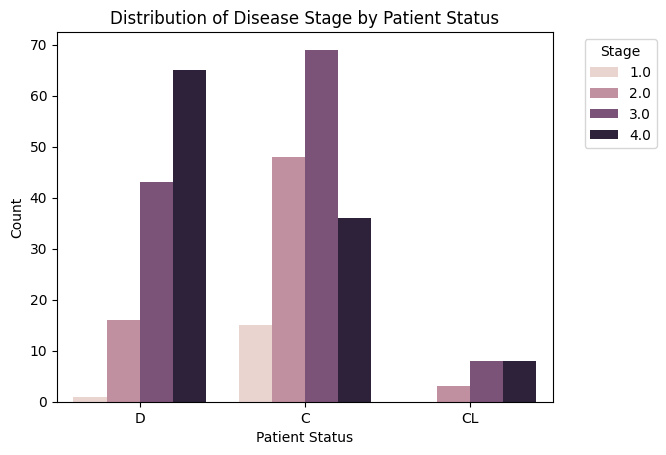

In [1961]:
sns.countplot(data=df, x='Status', hue='Stage')
plt.title("Distribution of Disease Stage by Patient Status")
plt.xlabel("Patient Status")
plt.ylabel("Count")

plt.legend(title="Stage", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()
plt.show()

`* No major differences are observed between males and females in terms of disease stage distribution across status categories.`

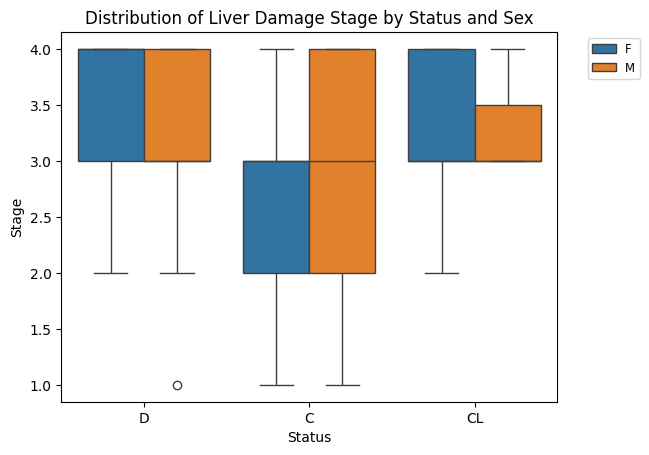

In [1962]:
ax=sns.boxplot(data=df,x='Status',y='Stage', hue='Sex')
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left', fontsize='small')
# title
plt.title('Distribution of Liver Damage Stage by Status and Sex')
plt.show()

# Train test split and Preprecessing

In [1963]:
X= df.drop(columns=['Stage', 'ID'])
y=df['Stage']

X_train,X_test,y_train,y_test= train_test_split(X,y,random_state=42)

In [1964]:
# column transformer
# numeric features
num_col=X_train.select_dtypes('number').columns
impute_median=SimpleImputer(strategy='median')
scaler=StandardScaler()
num_pipe=make_pipeline(impute_median,scaler)
num_tuple=('numeric', num_pipe,num_col)

# CATEGORICAL
cat_col=X_train.select_dtypes('object').columns.drop(['Edema'])
impute_Na=SimpleImputer(strategy='constant',fill_value='NA')
ohe_encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
cat_pipe=make_pipeline(impute_Na,ohe_encoder)
cat_tuple=('categorical',cat_pipe,cat_col)

#Ordinal features
ord_col=['Edema']
qual_col_order=['N','S','Y']
ordinal_cat_orders=[qual_col_order]
ohe_encoder_ord=OrdinalEncoder(categories=ordinal_cat_orders)
scaler_ord=StandardScaler()
ord_pipe=make_pipeline(ohe_encoder_ord,scaler_ord)
ord_tuple=('ordinal',ord_pipe,ord_col)

# column transformer
col_transformer=ColumnTransformer([num_tuple,cat_tuple, ord_tuple],remainder='drop' )
col_transformer.fit(X_train)
x_train_transformed=col_transformer.transform(X_train)
x_test_transformed=col_transformer.transform(X_test)

In [1965]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict



def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [1966]:
from imblearn.over_sampling import SMOTE,SMOTENC
smote = SMOTE()
X_train_sm, y_train_sm = smote.fit_resample(x_train_transformed, y_train)
y_train_sm.value_counts()

,count
Stage,
3.0,90
4.0,90
2.0,90
1.0,90


# Logistic Regression

In [1967]:
from sklearn.linear_model import LogisticRegression
# Make an instance of the model with default parameters
logreg = LogisticRegression(random_state=42)
# Fit the Logistic Regression model directly on the preprocessed and SMOTEd data
logreg.fit(X_train_sm, y_train_sm)

LogisticRegression(random_state=42)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.72      0.92      0.81        90
         2.0       0.58      0.51      0.54        90
         3.0       0.57      0.47      0.51        90
         4.0       0.71      0.72      0.72        90

    accuracy                           0.66       360
   macro avg       0.64      0.66      0.65       360
weighted avg       0.64      0.66      0.65       360



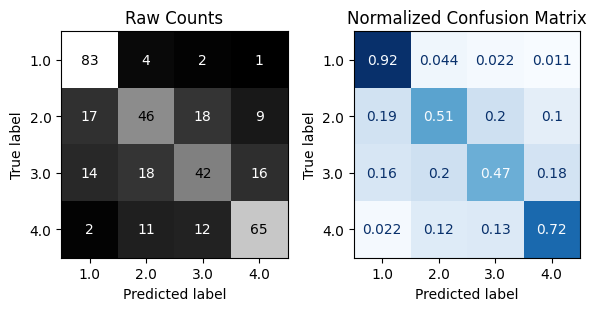


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.30      0.75      0.43         4
         2.0       0.14      0.12      0.13        17
         3.0       0.29      0.20      0.24        30
         4.0       0.55      0.67      0.60        27

    accuracy                           0.37        78
   macro avg       0.32      0.43      0.35        78
weighted avg       0.35      0.37      0.35        78



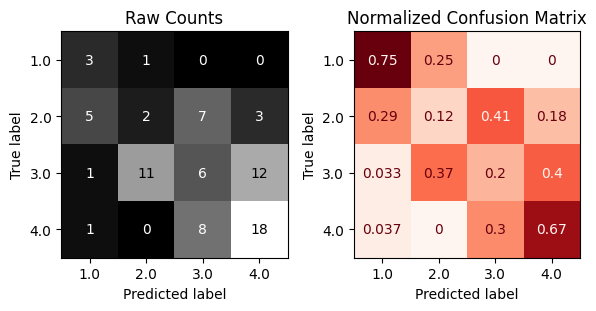

In [1968]:
evaluate_classification(logreg, X_train_sm, y_train_sm, x_test_transformed, y_test)

In [1969]:
logreg.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [1970]:
# Params compatible with penality='elasticnet'
elasticnet_params = {'solver' : ['saga'],
               'penalty' : ['elasticnet'],
                'l1_ratio': [0, 0.1, 0.2, 0.3, 0.4,
                                                 0.5, 0.6, 0.7, 0.8, 0.9, 1]}
# Params compatible with penality='l2'
l2_params = {'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                            'newton-cholesky', 'sag', 'saga'],
                  'penalty' : ['l2'],
                  'C': [0.0001, 0.001, 0.01, 0.1,
                                            1, 10, 100, 1000] }
# Params compatible with penality='l1'
l1_params = {'solver' : ['liblinear', 'saga'],
               'penalty' : ['l1'],
                'C': [0.0001, 0.001, 0.01, 0.1, 1,
                                          10, 100, 1000]}
# Params with no penality
none_params = {'solver' : ['lbfgs', 'newton-cg',
                                               'newton-cholesky', 'sag', 'saga'],
               'penalty' : [None]}
# Now make a list of the param dictionaries
param_grid = [l2_params, l1_params, elasticnet_params, none_params]

In [1971]:
## Warning: this gridsearch may take 5-10 minutes to run!!
# Instantiate gridsearch
gs = GridSearchCV(logreg, param_grid, verbose = 5, n_jobs = -1,
                  scoring='recall_macro')
# Fit the gs on the training data only
gs.fit(X_train_sm, y_train_sm)
gs.best_params_

Fitting 5 folds for each of 80 candidates, totalling 400 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'l1_ratio': 0.6, 'penalty': 'elasticnet', 'solver': 'saga'}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.71      0.90      0.79        90
         2.0       0.57      0.51      0.54        90
         3.0       0.58      0.47      0.52        90
         4.0       0.72      0.74      0.73        90

    accuracy                           0.66       360
   macro avg       0.65      0.66      0.65       360
weighted avg       0.65      0.66      0.65       360



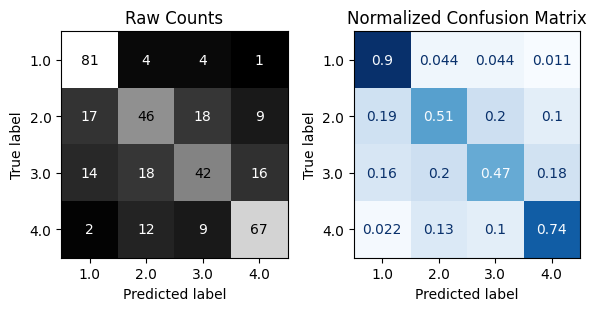


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.27      0.75      0.40         4
         2.0       0.20      0.18      0.19        17
         3.0       0.32      0.20      0.24        30
         4.0       0.55      0.67      0.60        27

    accuracy                           0.38        78
   macro avg       0.33      0.45      0.36        78
weighted avg       0.37      0.38      0.36        78



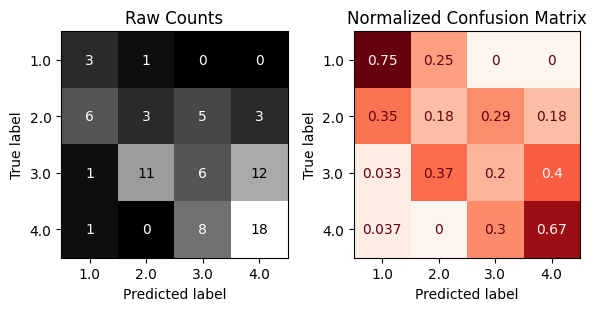

In [1972]:
# Evalaute the best model
best_logreg = gs.best_estimator_
evaluate_classification(best_logreg, X_train_sm, y_train_sm, x_test_transformed, y_test)

# **Permutation_importance**

In [1973]:
from sklearn.inspection import permutation_importance

# Use the transformed test data (x_test_transformed) instead of the original X_test
result = permutation_importance(best_logreg, x_test_transformed, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Correctly get feature names from the fitted ColumnTransformer
feature_names = col_transformer.get_feature_names_out()

importances = result.importances_mean
indices = np.argsort(importances)[::-1]  # Sort in descending order

In [1974]:
## can make the mean importances into a series
permutation_importances = pd.Series(result['importances_mean'],index=feature_names,
                           name = 'permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances

,permutation importance
categorical__Sex_F,1.410256e-02
categorical__Hepatomegaly_Y,1.025641e-02
numeric__Copper,7.692308e-03
categorical__Status_C,6.410256e-03
numeric__Alk_Phos,1.282051e-03
numeric__Cholesterol,5.551115e-18
categorical__Sex_M,0.000000e+00
categorical__Hepatomegaly_N,-1.282051e-03
numeric__Prothrombin,-3.846154e-03
categorical__Ascites_N,-5.128205e-03


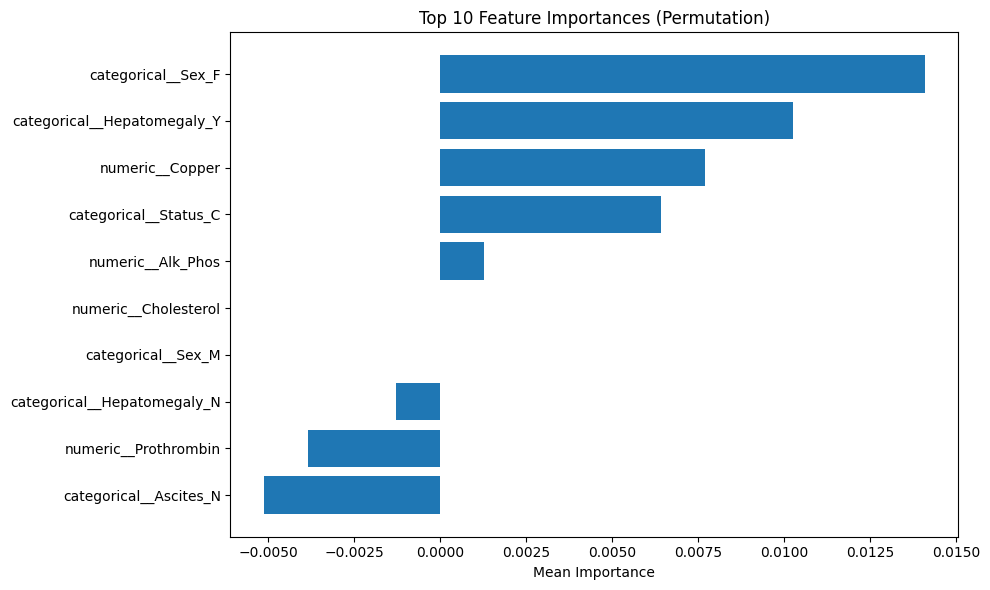

In [1975]:
top_n = 10
top_features = permutation_importances.head(top_n)
plt.figure(figsize=(10,6))
plt.barh(top_features.index[::-1], top_features.values[::-1], align='center')
plt.title("Top 10 Feature Importances (Permutation)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

<Axes: xlabel='Status', ylabel='Stage'>

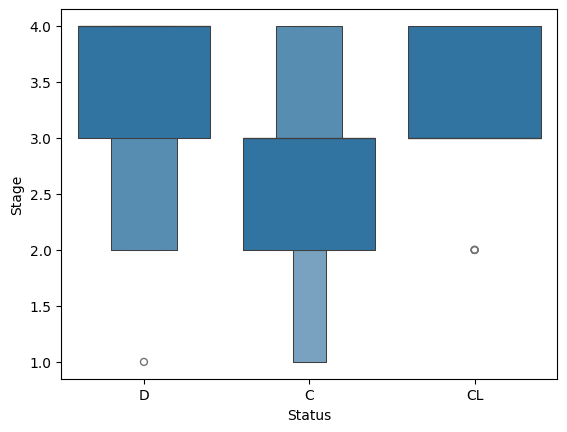

In [1976]:
sns.boxenplot(data=df,x='Status',y='Stage')

<Axes: xlabel='Stage', ylabel='Prothrombin'>

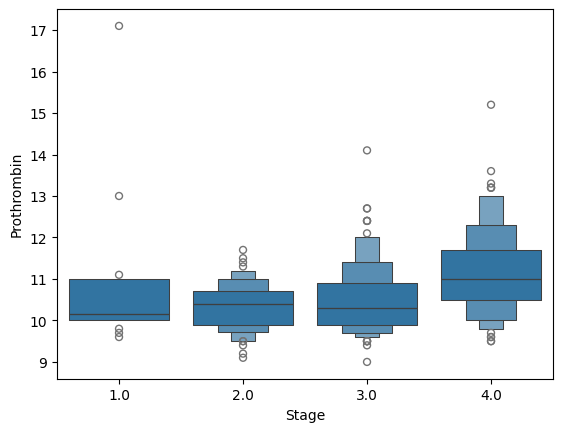

In [1977]:
sns.boxenplot(data=df,x='Stage',y='Prothrombin')

# **Feature engeneering**

In [1978]:
from sklearn.decomposition import PCA

# Instantiate & fit data using PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_sm)
X_test_pca = pca.transform(x_test_transformed)
#ARRAY
print(X_train_pca[:5])

[[ 1.16377097 -1.86211766  0.24823833]
 [ 0.57082525  0.69343935 -0.32216492]
 [-0.66700316 -0.38190908  0.08571266]
 [ 1.20993313 -0.17502215 -1.01284409]
 [ 2.17913193 -1.06553123  0.93161364]]


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.58      0.86      0.69        90
         2.0       0.43      0.33      0.38        90
         3.0       0.47      0.37      0.41        90
         4.0       0.62      0.60      0.61        90

    accuracy                           0.54       360
   macro avg       0.52      0.54      0.52       360
weighted avg       0.52      0.54      0.52       360



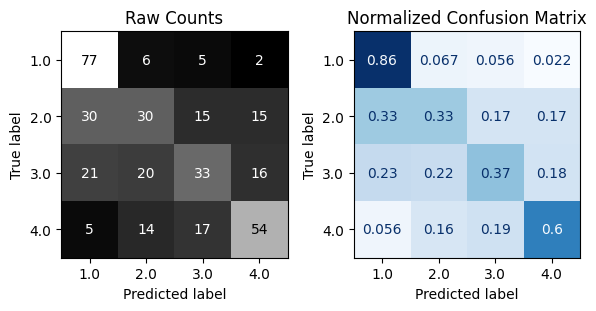


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.17      0.75      0.27         4
         2.0       0.22      0.12      0.15        17
         3.0       0.42      0.33      0.37        30
         4.0       0.63      0.63      0.63        27

    accuracy                           0.41        78
   macro avg       0.36      0.46      0.36        78
weighted avg       0.44      0.41      0.41        78



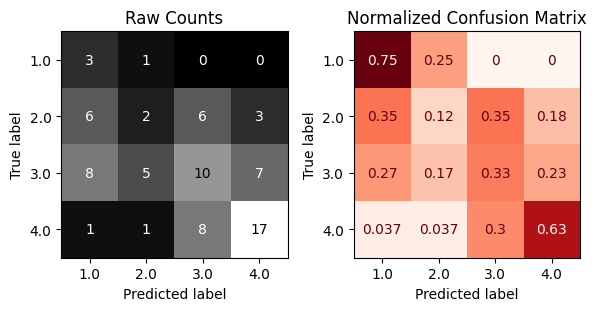

Training time was: 0:00:00.033982


In [1979]:
import datetime as dt

# Record the start time
start = dt.datetime.now()

clf = LogisticRegression(random_state=42)
clf.fit(X_train_pca, y_train_sm)

# Record the end time and calc duration
end = dt.datetime.now()
dur_pca = end-start

evaluate_classification(clf, X_train_pca,y_train_sm, X_test_pca, y_test)
print(f'Training time was: {dur_pca}')

In [1980]:
# Initialize and fit PCA
pca = PCA()
pca.fit(X_train_sm, y_train)

PCA()

In [1981]:
# Determine how much variance is explained by each PC
explained = pd.Series(pca.explained_variance_ratio_, name='Explained Variance Ratio')
explained

,Explained Variance Ratio
0,2.648030e-01
1,1.255511e-01
2,8.241760e-02
3,7.064900e-02
4,6.333751e-02
5,5.513210e-02
6,4.860155e-02
7,4.706451e-02
8,4.463845e-02
9,3.931109e-02


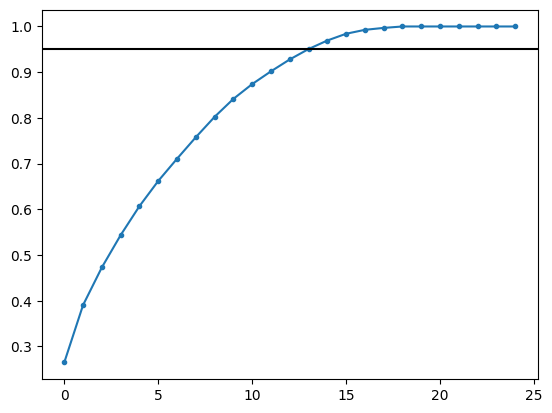

In [1982]:
# plot the cumulative sum of the percentage of explained variance for each component and those before it.
ax = explained.cumsum().plot(marker='.')
# add a line to mark .9 (or 90%) variance explained
ax.axhline(.95, color='k');

In [1983]:
# Define PCA to address 95% of the variance
pca95 = PCA(n_components=.99)
# fit and transform on training data
X_train_pca95 = pca95.fit_transform(X_train_sm)
# transform test data
X_test_pca95 = pca95.transform(x_test_transformed)
# obtain the number of PCs used
pca95.n_components_

np.int64(17)

* Timing when 95% of Variance is Explained with PCSs

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        90
         2.0       1.00      1.00      1.00        90
         3.0       1.00      1.00      1.00        90
         4.0       1.00      1.00      1.00        90

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



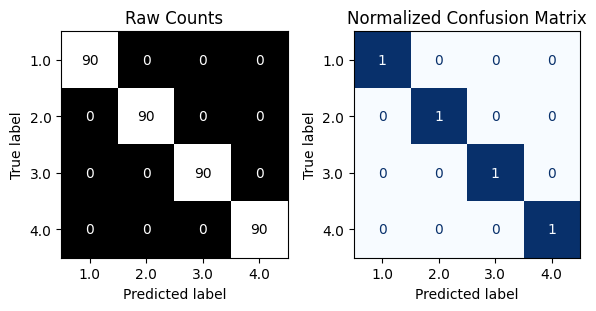


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.33      0.25      0.29         4
         2.0       0.29      0.24      0.26        17
         3.0       0.24      0.20      0.22        30
         4.0       0.53      0.70      0.60        27

    accuracy                           0.38        78
   macro avg       0.35      0.35      0.34        78
weighted avg       0.35      0.38      0.36        78



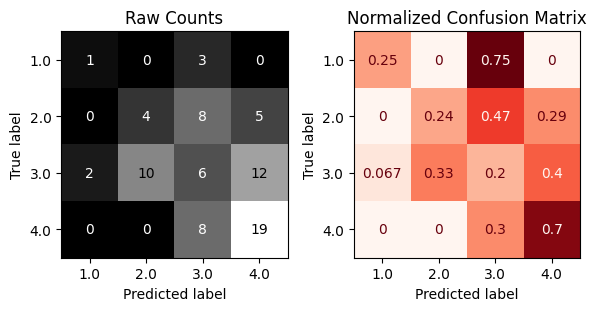

Training time was: 0:00:00.597094


In [1984]:
# Record the start time
start = dt.datetime.now()

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_pca95, y_train_sm)

# Record the end time and calc duration
end = dt.datetime.now()
dur_pca_98 = end-start

evaluate_classification(clf, X_train_pca95,y_train_sm, X_test_pca95, y_test)
print(f'Training time was: {dur_pca_98}')

# Kmeans as a feature engeneering

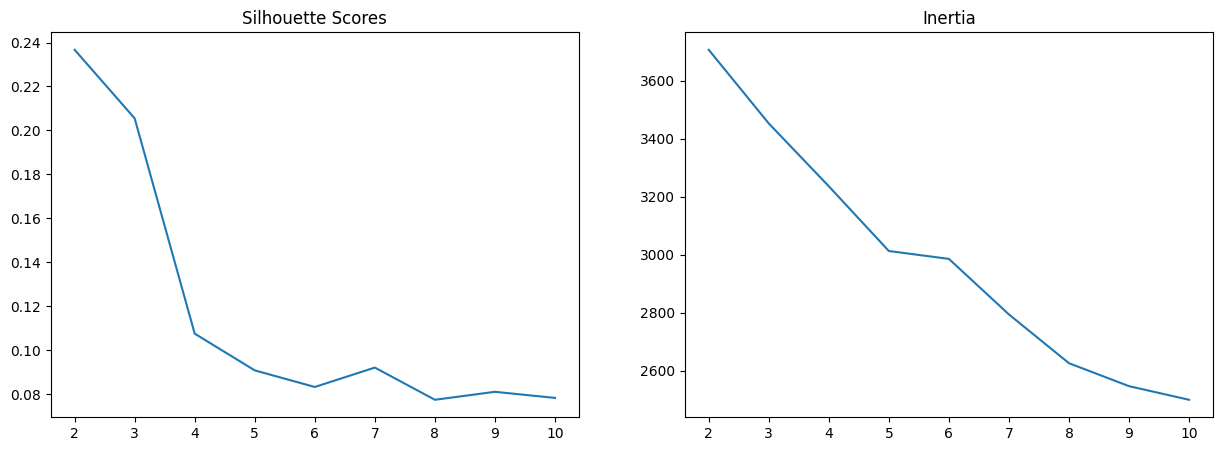

In [1985]:
# kmeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Transform the original feature data (X) using the pre-fitted ColumnTransformer
# X was defined as df.drop(columns=['Stage', 'ID'])
X_kmeans = col_transformer.transform(X)

ks = range(2,11)
sils = []
inertias = []
for k in ks:
  kmeans = KMeans(n_clusters=k, n_init = 'auto', random_state=42)
  kmeans.fit(X_kmeans) # Fit KMeans on the transformed numerical data
  sils.append(silhouette_score(X_kmeans, kmeans.labels_)) # Calculate silhouette score on the transformed data
  inertias.append(kmeans.inertia_)
#plot inertias and silhouette scores for each number of clusters.
fig, axes = plt.subplots(1,2, figsize=(15,5))
axes[0].plot(ks, sils)
axes[0].set_title('Silhouette Scores')
axes[0].set_xticks(ks)
axes[1].plot(ks, inertias)
axes[1].set_title('Inertia')
axes[1].set_xticks(ks);

In [1986]:
kmeans = KMeans(n_clusters=4, n_init='auto', random_state=42)

# Fit KMeans on the SMOTEd training data (x_train_transformed already includes preprocessing)
kmeans.fit(X_train_sm)

# Get cluster labels for training and test data
train_clusters = kmeans.predict(X_train_sm)
test_clusters = kmeans.predict(x_test_transformed)

# Add cluster labels as new features to the existing transformed data
# Assuming X_train_sm and x_test_transformed are numpy arrays, concatenate the new feature
X_train_sm_clustered = np.hstack((X_train_sm, train_clusters.reshape(-1, 1)))
x_test_transformed_clustered = np.hstack((x_test_transformed, test_clusters.reshape(-1, 1)))

print("Shape of X_train_sm_clustered:", X_train_sm_clustered.shape)
print("Shape of x_test_transformed_clustered:", x_test_transformed_clustered.shape)

Shape of X_train_sm_clustered: (360, 26)
Shape of x_test_transformed_clustered: (78, 26)


In [1987]:
clf_clustered = LogisticRegression(random_state=42)
clf_clustered.fit(X_train_sm_clustered, y_train_sm)

LogisticRegression(random_state=42)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.72      0.92      0.81        90
         2.0       0.60      0.51      0.55        90
         3.0       0.59      0.49      0.54        90
         4.0       0.70      0.72      0.71        90

    accuracy                           0.66       360
   macro avg       0.65      0.66      0.65       360
weighted avg       0.65      0.66      0.65       360



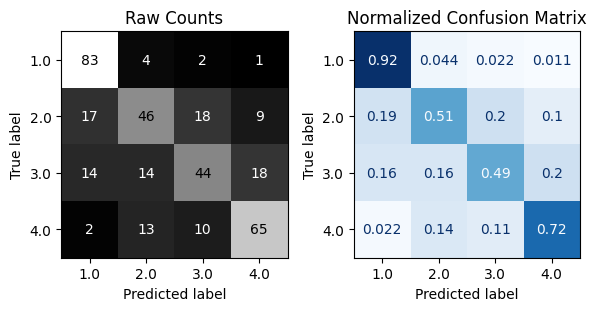


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.27      0.75      0.40         4
         2.0       0.23      0.18      0.20        17
         3.0       0.32      0.23      0.27        30
         4.0       0.56      0.67      0.61        27

    accuracy                           0.40        78
   macro avg       0.35      0.46      0.37        78
weighted avg       0.38      0.40      0.38        78



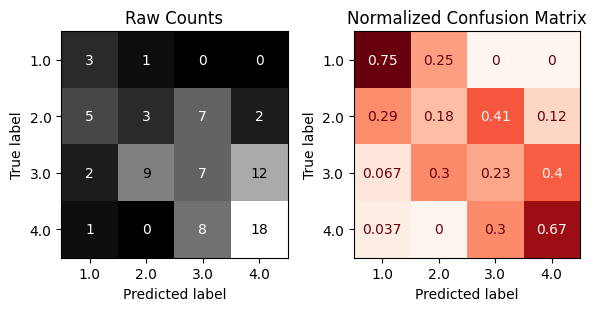

In [1988]:
# Evaluate the model with the clustered data
evaluate_classification(clf_clustered, X_train_sm_clustered, y_train_sm, x_test_transformed_clustered, y_test)

# **Feature selection**
|Wrapper|

In [1989]:
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SequentialFeatureSelector

lg=LogisticRegression(random_state=42)
# Instantiate the SequentialFeatureSelector
sk_sfs = SequentialFeatureSelector(clf_clustered, n_features_to_select=15,
                                direction = 'forward', cv=2,
                                 n_jobs=-1)
sk_sfs.fit(X_train_sm_clustered,y_train_sm)

SequentialFeatureSelector(cv=2, estimator=LogisticRegression(random_state=42),
                          n_features_to_select=15, n_jobs=-1)

In [1990]:
features_to_keep = sk_sfs.support_
# Only include the features selected
X_train_15 = X_train_sm_clustered[:,features_to_keep]
X_test_15 = x_test_transformed_clustered[:,features_to_keep]
X_train_15.shape

(360, 15)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.66      0.88      0.76        90
         2.0       0.60      0.47      0.53        90
         3.0       0.55      0.46      0.50        90
         4.0       0.69      0.74      0.72        90

    accuracy                           0.64       360
   macro avg       0.63      0.64      0.62       360
weighted avg       0.63      0.64      0.62       360



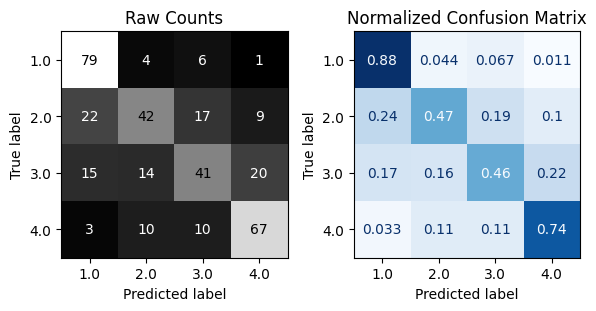


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         1.0       0.27      0.75      0.40         4
         2.0       0.27      0.24      0.25        17
         3.0       0.38      0.27      0.31        30
         4.0       0.58      0.67      0.62        27

    accuracy                           0.42        78
   macro avg       0.38      0.48      0.40        78
weighted avg       0.42      0.42      0.41        78



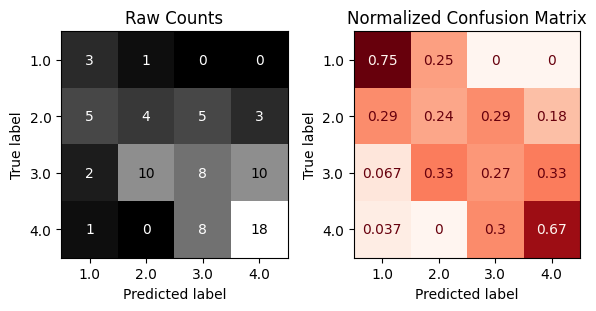

In [1991]:
lr_clf = LogisticRegression(random_state=42)
# Fit on selected features
lr_clf.fit(X_train_15, y_train_sm)
# Evaluate with custom function
evaluate_classification(lr_clf, X_train_15, y_train_sm, X_test_15, y_test)

# Top 10 features

In [1992]:
from sklearn.inspection import permutation_importance

# feature importances from the feature that has been collected from the wrapper method ung the tuned data from PCA
result = permutation_importance(lr_clf, X_test_15, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Correctly get feature names from the fitted ColumnTransformer
feature_names = col_transformer.get_feature_names_out()

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

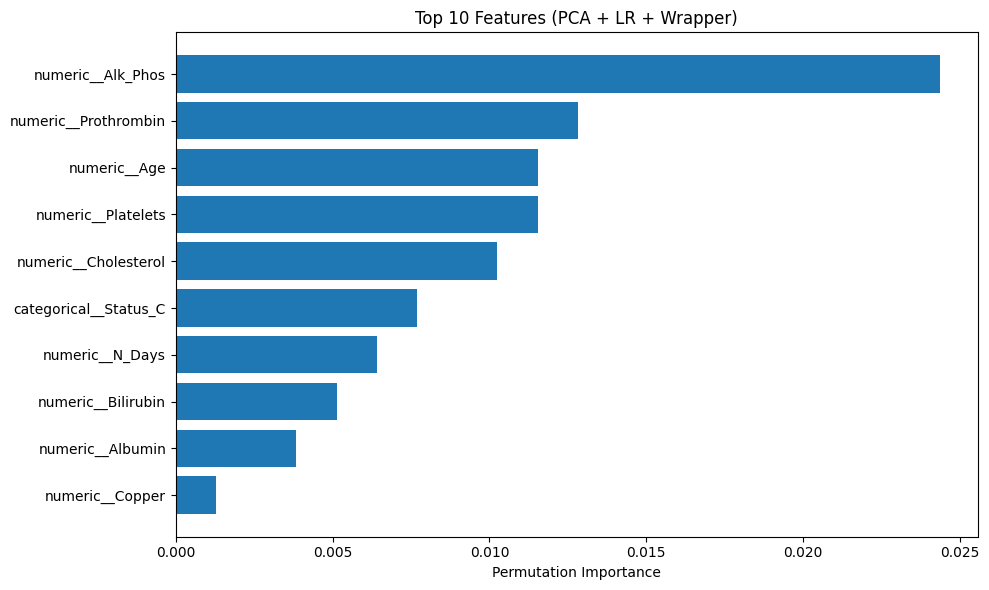

In [1993]:
import matplotlib.pyplot as plt

top_n = 10
top_features = [feature_names[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

plt.figure(figsize=(10,6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Permutation Importance")
plt.title("Top 10 Features (PCA + LR + Wrapper)")
plt.tight_layout()
plt.show()

# **Deep Learning**

In [1994]:
#Keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras import metrics
from tensorflow.keras.layers import Dense, Dropout

#Sci-kit Learn
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [1995]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):

    # Get the classification report
    report = classification_report(y_true, y_pred)
    ## Print header and report
    header = "-"*70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    ## CONFUSION MATRICES SUBPLOTS
    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # create a confusion matrix  of raw counts
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', values_format="d", colorbar=colorbar,
                ax = axes[0],);
    axes[0].set_title("Raw Counts")

    # create a confusion matrix with the test data
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, values_format=".2f", colorbar=colorbar,
                ax = axes[1]);
    axes[1].set_title("Normalized Confusion Matrix")

    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()

    # Return dictionary of classification_report
    if output_dict==True:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict

In [1996]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

In [1997]:
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
# encode labels
encoder = LabelEncoder()

encoder.fit(y_train_sm)
y_train_enc = encoder.transform(y_train_sm)
y_test_enc = encoder.transform(y_test)

# make a record of the classes, in order of the encoding, in case we want to
# translate predictions into fish names later.
classes = encoder.classes_

# binarize labels
binarizer = LabelBinarizer()

binarizer.fit(y_train_enc)
y_train_bin = binarizer.transform(y_train_enc)
y_test_bin = binarizer.transform(y_test_enc)

# check results
print('Original Target')
print(y_train.head())

print('\nEncoded Target')
print(y_train_enc[:5])

print('\nBinarized Target')
print(y_train_bin[:5])

Original Target
119    3.0
258    3.0
244    3.0
204    3.0
137    3.0
Name: Stage, dtype: float64

Encoded Target
[2 2 2 2 2]

Binarized Target
[[0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]]


model sequential

In [1998]:
# Define input shape
input_shape = X_train_sm.shape[1]
input_shape

25

In [1999]:
# Define number of classes
num_classes = len(classes)
num_classes


4

In [2000]:
# Build multiclass classification model within function
from tensorflow.keras.regularizers import l2
def build_model():
    # Instantiate Model
    model = Sequential()

    # First hidden layer
    model.add(Dense(8, # How many neurons you have in your first hidden layer
                input_dim =input_shape,# What is the shape of your input features (number of columns)
                activation = 'relu')) # What activation function are you using?
    #model.add(Dense(4, activation = 'relu'))
    #model.add(Dense(4, activation = 'relu',kernel_regularizer=l2(0.005)))
    model.add(Dropout(.3))
    #Output layer
    model.add(Dense(num_classes, activation = 'softmax'))


    # Compile Model
    model.compile(loss = 'categorical_crossentropy', optimizer = 'adam',
             metrics=['accuracy', metrics.Precision(), metrics.Recall()])
    return model

In [2001]:
# Call our build function to build model
multi_model = build_model()

# Get model summary
multi_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 8)              │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244 (976.00 B)

 Trainable params: 244 (976.00 B)

 Non-trainable params: 0 (0.00 B)

In [2002]:
#early_stop = EarlyStopping( patience=60)
history = multi_model.fit(X_train_sm, y_train_bin,
                          validation_data=(x_test_transformed, y_test_bin),
                          epochs=100,
                          verbose=0)

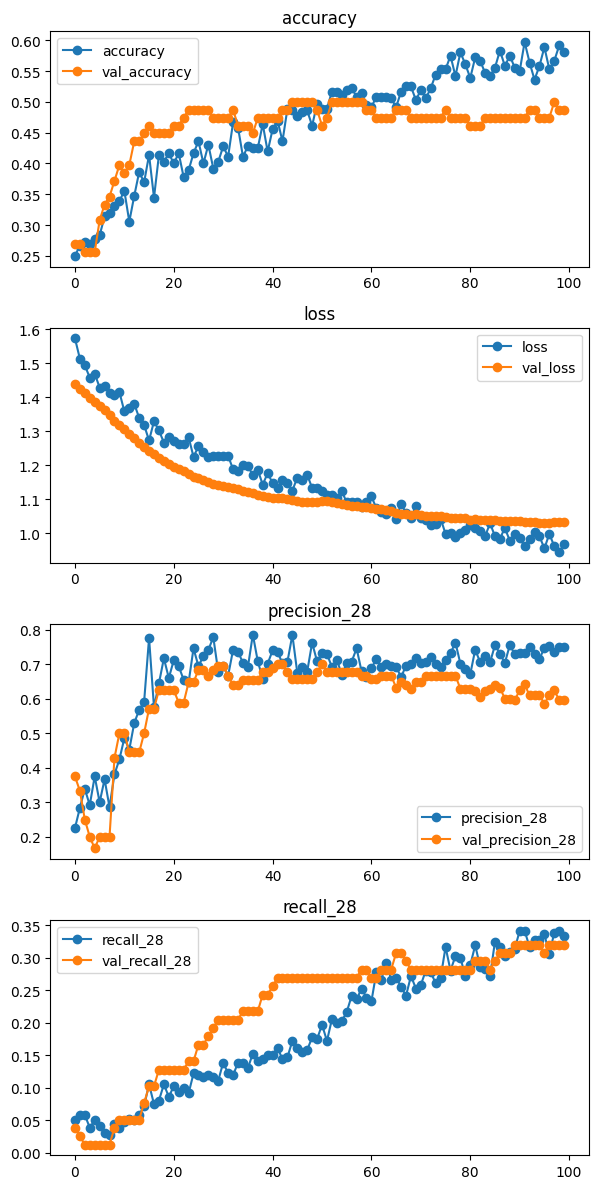

In [2003]:
# plot learning history

plot_history(history);

In [2004]:
# get raw predictions
raw_pred = multi_model.predict(x_test_transformed)

# display predictions and binarized true labels
print('Raw Predictions\n', raw_pred[:5])
print('\nbinarized y_test\n', y_test_bin[:5])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Raw Predictions
 [[2.06536133e-04 1.19647540e-01 1.56894818e-01 7.23251164e-01]
 [4.45794649e-05 9.78274047e-02 1.41867191e-01 7.60260761e-01]
 [5.23528516e-01 2.47256875e-01 1.81198046e-01 4.80166003e-02]
 [3.70940238e-01 1.85885534e-01 3.58284652e-01 8.48895460e-02]
 [5.46888588e-03 1.24959014e-01 6.77286446e-01 1.92285568e-01]]

binarized y_test
 [[0 0 0 1]
 [0 0 0 1]
 [1 0 0 0]
 [1 0 0 0]
 [0 0 1 0]]


In [2005]:
# convert predictions and labels into integers representing each fish class.
y_pred = np.argmax(raw_pred, axis=1)
y_true = np.argmax(y_test_bin, axis=1)

print('integer predictions', y_pred)
print('integer true labels', y_true)

integer predictions [3 3 0 0 2 3 3 3 3 1 3 3 3 0 0 3 3 3 2 3 2 1 3 3 3 3 3 1 2 2 0 3 3 2 3 1 3
 3 1 3 0 0 3 3 3 3 3 1 0 3 3 2 2 3 3 2 1 3 0 0 3 3 0 3 3 2 1 2 3 0 1 2 3 3
 3 0 3 0]
integer true labels [3 3 0 0 2 2 3 2 2 2 3 3 3 2 0 3 2 2 1 3 3 1 1 3 2 2 3 1 3 2 2 3 3 1 3 1 2
 3 1 1 1 1 3 3 1 2 2 2 2 3 3 3 2 3 3 1 1 2 1 2 2 2 2 3 1 2 2 2 3 2 3 2 2 1
 3 0 2 1]


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.29      1.00      0.44         4
           1       0.56      0.29      0.38        17
           2       0.50      0.20      0.29        30
           3       0.53      0.85      0.66        27

    accuracy                           0.49        78
   macro avg       0.47      0.59      0.44        78
weighted avg       0.51      0.49      0.44        78



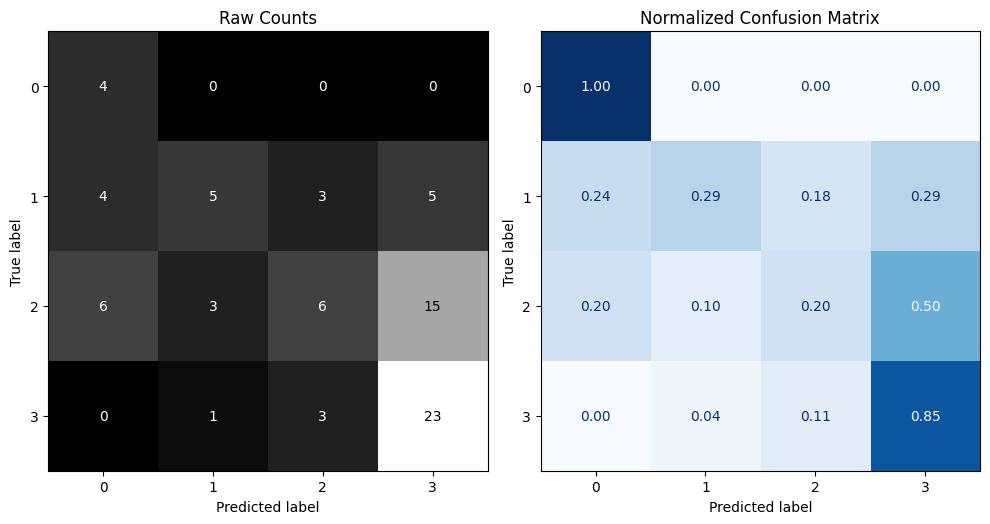

In [2006]:
# Getting Sklearn Metrics
classification_metrics(y_true, y_pred, label='Test Data', figsize=(10,8))

In [2007]:
# get raw predictions
raw_pred = multi_model.predict(X_train_sm)

# display predictions and binarized true labels
print('Raw Predictions\n', raw_pred[:5])
print('\nbinarized y_test\n', y_test_bin[:5])

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Raw Predictions
 [[0.01676036 0.0656572  0.479068   0.43851444]
 [0.00372339 0.18352753 0.23476683 0.57798225]
 [0.01219714 0.14141062 0.49098054 0.35541165]
 [0.08955627 0.30623025 0.34845552 0.25575796]
 [0.02395291 0.17965882 0.41261092 0.38377735]]

binarized y_test
 [[0 0 0 1]
 [0 0 0 1]
 [1 0 0 0]
 [1 0 0 0]
 [0 0 1 0]]


In [2008]:
# convert predictions and labels into integers representing each fish class.
y_pred = np.argmax(raw_pred, axis=1)
y_true = np.argmax(y_train_bin, axis=1)

print('integer predictions', y_pred)
print('integer true labels', y_true)

integer predictions [2 3 2 2 2 2 3 0 2 2 2 3 3 2 1 3 0 0 0 2 0 3 2 0 0 3 3 3 3 2 3 2 0 0 0 3 0
 2 3 1 3 1 3 0 0 2 3 1 3 1 3 0 2 2 2 3 2 3 1 1 0 3 0 3 3 2 3 3 3 3 2 1 2 3
 1 2 3 3 3 1 3 1 3 2 1 0 3 3 0 2 1 1 0 1 1 0 3 0 2 2 1 1 3 2 2 3 2 3 1 3 3
 3 3 3 1 2 1 3 3 1 1 0 3 3 1 0 2 0 3 1 3 0 3 3 3 3 1 3 0 3 2 3 2 0 1 2 3 1
 1 2 1 1 3 1 3 3 2 2 3 2 3 2 1 3 3 1 1 2 0 3 1 1 2 3 0 0 0 1 3 3 0 3 3 3 3
 2 3 2 0 1 3 3 3 3 3 3 3 1 3 1 1 3 2 2 1 1 1 1 3 0 3 3 2 3 3 2 1 2 3 0 0 3
 3 3 1 2 0 2 3 2 0 0 2 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3 0 1 2 1 2 1 1 2 1 1 1 1 1 1 1 1 1 1
 1 3 0 0 3 2 1 3 3 0 1 3 0 1 1 0 1 1 0 3 1 3 3 3 0 3 3]
integer true labels [2 2 2 2 2 2 3 1 2 2 2 2 3 2 1 3 0 1 0 2 2 3 1 0 0 2 1 3 3 1 1 3 2 2 1 3 2
 2 3 1 2 3 2 1 1 2 3 2 3 1 2 2 3 3 2 3 2 3 3 1 2 3 3 2 1 3 3 2 1 3 2 3 2 3
 2 2 3 3 3 2 2 1 2 2 1 2 3 2 2 2 1 2 2 1 1 2 3 1 2 2 0 2 3 3 1 3 1 3 1 3 1
 1 3

----------------------------------------------------------------------
 Classification Metrics: Train Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.69      0.93      0.80        90
           1       0.60      0.50      0.55        90
           2       0.62      0.40      0.49        90
           3       0.67      0.79      0.72        90

    accuracy                           0.66       360
   macro avg       0.65      0.66      0.64       360
weighted avg       0.65      0.66      0.64       360



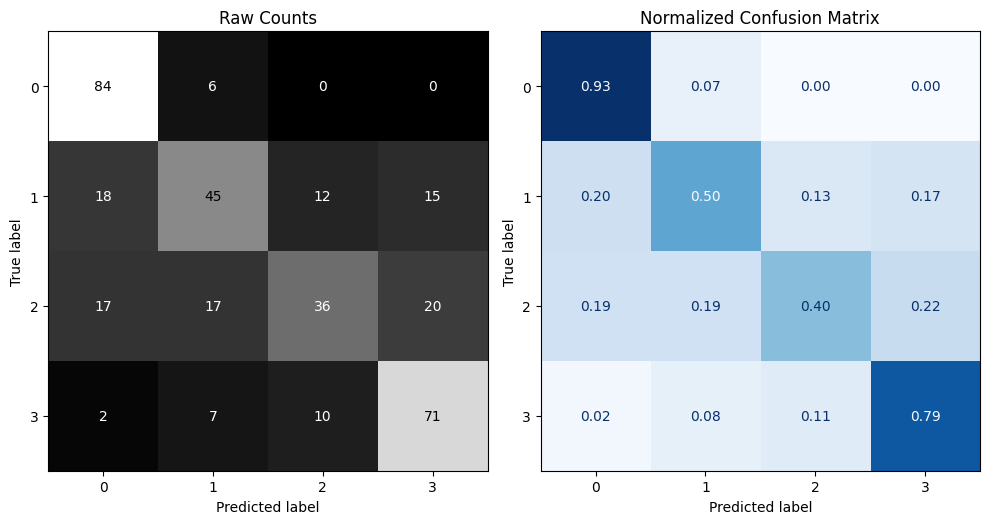

In [2009]:
# Getting Sklearn Metrics
classification_metrics(y_true, y_pred, label='Train Data', figsize=(10,8))